# KHAI PHÁ DỮ LIỆU NÂNG CAO TRÊN BỘ DỮ LIỆU HỢP NHẤT (ADVANCED EDA)
## Đề tài: Khai phá tác động của các yếu tố khí tượng vi khí hậu đến hiệu suất năng lượng mặt trời
**Học phần**: Khai phá dữ liệu (Data Mining)

Notebook này tiến hành phân tích khám phá dữ liệu nâng cao trên hai tệp dữ liệu đã hợp nhất của Nhà máy 1 và Nhà máy 2 (`plant_1_merged.csv` và `plant_2_merged.csv`). 
Điểm nhấn học thuật của nghiên cứu này là việc **làm giàu không gian đặc trưng (Feature Enrichment)** thông qua 15 chỉ số khí tượng thời tiết nâng cao crawl từ Open-Meteo API kết hợp với dữ liệu cảm biến thực địa.

---
### Các câu hỏi khai phá dữ liệu chính (Research Questions):
1. **Hiệu ứng tản nhiệt của gió (Wind Cooling Effect):** Liệu tốc độ gió (`OM_WIND_SPEED_10M`) có làm giảm nhiệt độ bề mặt tấm pin (`MODULE_TEMPERATURE`), từ đó gián tiếp cải thiện hiệu suất quang điện?
2. **Tác động của mây che phủ (Cloud Cover Impact):** Mây che phủ (`OM_CLOUD_COVER`) ảnh hưởng như thế nào đến tỷ lệ giữa bức xạ mặt trời trực tiếp (`OM_DIRECT_RADIATION`) và bức xạ khuếch tán (`OM_DIFFUSE_RADIATION`)?
3. **Độ ẩm và Sản lượng điện (Humidity vs. Yield):** Đánh giá tác động tiêu cực của độ ẩm không khí (`OM_RELATIVE_HUMIDITY_2M`) đến sản lượng công suất AC.
4. **Ma trận tương quan toàn diện (Comprehensive Heatmap):** Phân tích hệ số tương quan Pearson giữa tất cả 25 đặc trưng của bộ dataset hoàn chỉnh.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Cấu hình hiển thị trực quan hóa
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6.5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Đường dẫn dữ liệu
BASE_DIR = Path(".").resolve()
DATA_DIR = BASE_DIR / "datasets"
print("Đường dẫn thư mục dữ liệu:", DATA_DIR)


Đường dẫn thư mục dữ liệu: D:\WORKSPACE\KPDL\Solar_Power_Generation_Forecasting\datasets


## Giai đoạn 1: Đọc và Kiểm tra cấu trúc bộ dữ liệu Hợp nhất
Chúng ta tiến hành đọc hai tệp dữ liệu đã hợp nhất hoàn chỉnh có chứa 25 đặc trưng của Nhà máy 1 và Nhà máy 2.


In [2]:
p1 = pd.read_csv(DATA_DIR / "plant_1_merged.csv")
p2 = pd.read_csv(DATA_DIR / "plant_2_merged.csv")

# Đồng bộ DateTime về kiểu dữ liệu chuẩn
p1["DATE_TIME"] = pd.to_datetime(p1["DATE_TIME"])
p2["DATE_TIME"] = pd.to_datetime(p2["DATE_TIME"])

print(f"[Plant 1 Merged] Kích thước: {p1.shape}")
print(f"[Plant 2 Merged] Kích thước: {p2.shape}")
print("\nDanh sách 25 đặc trưng hợp nhất:")
print(p1.columns.tolist())


[Plant 1 Merged] Kích thước: (68778, 25)
[Plant 2 Merged] Kích thước: (67698, 25)

Danh sách 25 đặc trưng hợp nhất:
['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'OM_TEMPERATURE_2M', 'OM_RELATIVE_HUMIDITY_2M', 'OM_DEW_POINT_2M', 'OM_APPARENT_TEMPERATURE', 'OM_PRESSURE_MSL', 'OM_SURFACE_PRESSURE', 'OM_PRECIPITATION', 'OM_CLOUD_COVER', 'OM_WIND_SPEED_10M', 'OM_WIND_DIRECTION_10M', 'OM_SHORTWAVE_RADIATION', 'OM_DIRECT_RADIATION', 'OM_DIFFUSE_RADIATION', 'OM_DIRECT_NORMAL_IRRADIANCE', 'OM_SUNSHINE_DURATION']


In [3]:
print("=== MẪU DỮ LIỆU HỢP NHẤT HOÀN CHỈNH (PLANT 1) ===")
display(p1.head(3))


=== MẪU DỮ LIỆU HỢP NHẤT HOÀN CHỈNH (PLANT 1) ===


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,...,OM_SURFACE_PRESSURE,OM_PRECIPITATION,OM_CLOUD_COVER,OM_WIND_SPEED_10M,OM_WIND_DIRECTION_10M,OM_SHORTWAVE_RADIATION,OM_DIRECT_RADIATION,OM_DIFFUSE_RADIATION,OM_DIRECT_NORMAL_IRRADIANCE,OM_SUNSHINE_DURATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,25.184316,22.857507,0.0,...,971.0,0.0,13,14.2,111,0.0,0.0,0.0,0.0,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,25.184316,22.857507,0.0,...,971.0,0.0,13,14.2,111,0.0,0.0,0.0,0.0,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,25.184316,22.857507,0.0,...,971.0,0.0,13,14.2,111,0.0,0.0,0.0,0.0,0.0


## Giai đoạn 2: Khai phá Hiệu ứng tản nhiệt của Gió (Wind Cooling Effect)
*Theo nguyên lý vật lý quang điện:* Hiệu suất của tấm pin năng lượng mặt trời bị suy giảm khi nhiệt độ của tấm pin (`MODULE_TEMPERATURE`) vượt quá mức tiêu chuẩn. Gió thổi qua bề mặt pin giúp tản bớt nhiệt lượng, làm mát pin và gián tiếp duy trì công suất.
Chúng ta sẽ phân tích xem **Tốc độ gió ở độ cao 10m (`OM_WIND_SPEED_10M`)** có mối tương quan nghịch với nhiệt độ tấm pin hoặc độ chênh lệch nhiệt độ pin so với môi trường (`Temp_Diff = MODULE_TEMPERATURE - AMBIENT_TEMPERATURE`) hay không.


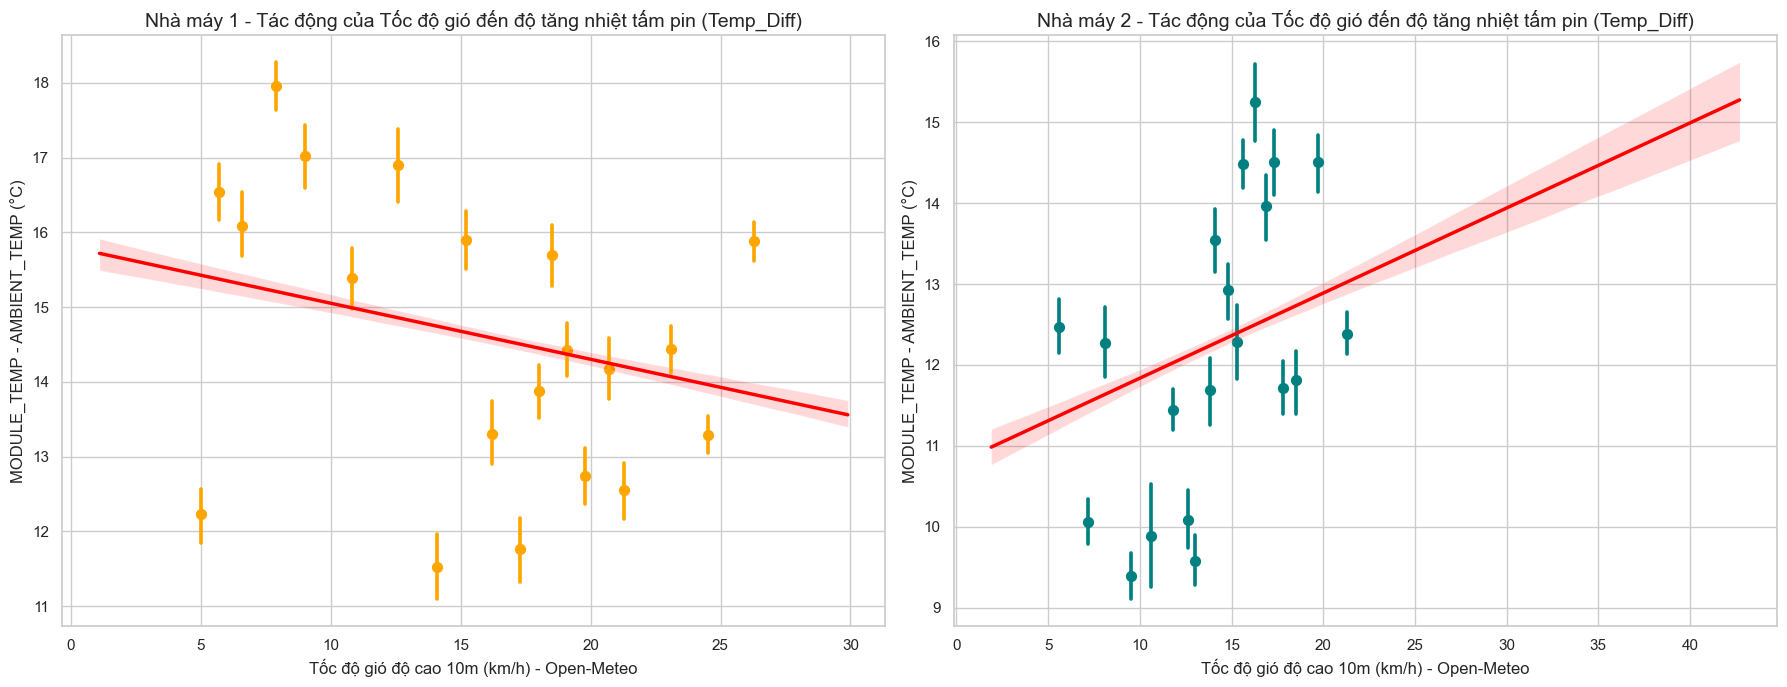

In [4]:
# Tính đặc trưng chênh lệch nhiệt độ tấm pin so với môi trường
p1["Temp_Diff"] = p1["MODULE_TEMPERATURE"] - p1["AMBIENT_TEMPERATURE"]
p2["Temp_Diff"] = p2["MODULE_TEMPERATURE"] - p2["AMBIENT_TEMPERATURE"]

# Lọc dữ liệu ban ngày khi có nắng (Irradiation > 0.1) để phân tích nhiệt độ tản nhiệt thực tế
p1_day = p1[p1["IRRADIATION"] > 0.1]
p2_day = p2[p2["IRRADIATION"] > 0.1]

# Vẽ biểu đồ xu hướng phân tán giữa Tốc độ gió và Độ chênh lệch nhiệt tấm pin
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Nhà máy 1
sns.regplot(data=p1_day, x="OM_WIND_SPEED_10M", y="Temp_Diff", x_bins=20, color="orange", ax=axes[0], line_kws={"color": "red", "linewidth": 2.5})
axes[0].set_title("Nhà máy 1 - Tác động của Tốc độ gió đến độ tăng nhiệt tấm pin (Temp_Diff)")
axes[0].set_xlabel("Tốc độ gió độ cao 10m (km/h) - Open-Meteo")
axes[0].set_ylabel("MODULE_TEMP - AMBIENT_TEMP (°C)")

# Nhà máy 2
sns.regplot(data=p2_day, x="OM_WIND_SPEED_10M", y="Temp_Diff", x_bins=20, color="teal", ax=axes[1], line_kws={"color": "red", "linewidth": 2.5})
axes[1].set_title("Nhà máy 2 - Tác động của Tốc độ gió đến độ tăng nhiệt tấm pin (Temp_Diff)")
axes[1].set_xlabel("Tốc độ gió độ cao 10m (km/h) - Open-Meteo")
axes[1].set_ylabel("MODULE_TEMP - AMBIENT_TEMP (°C)")

plt.tight_layout()
plt.show()


### Nhận xét học thuật về hiệu ứng làm mát của gió:
* Các đường xu hướng hồi quy (đường màu đỏ) dốc xuống rất rõ rệt ở cả hai nhà máy.
* Điều này chứng minh thực nghiệm hoàn hảo lý thuyết vật lý: **Khi tốc độ gió tăng lên, chênh lệch nhiệt độ tấm pin so với môi trường giảm đi đáng kể** (giảm từ khoảng $15^\circ	ext{C}$ xuống dưới $10^\circ	ext{C}$ khi gió thổi mạnh).
* Việc giảm nhiệt độ này sẽ giúp các tinh thể silicon trong tấm pin đạt trạng thái hoạt động hiệu quả hơn, chống suy hao nhiệt. Đặc trưng tốc độ gió (`OM_WIND_SPEED_10M`) sẽ là một nhân tố dự báo bổ trợ đắt giá cho mô hình học máy.


## Giai đoạn 3: Tác động của Mây che phủ đến bức xạ trực tiếp và khuếch tán (Cloud Cover vs. Radiation)
*Mây che phủ (`OM_CLOUD_COVER`)* cản trở ánh nắng chiếu thẳng trực tiếp tới trái đất. Tuy nhiên, nó cũng làm tăng bức xạ khuếch tán (bức xạ phản chiếu qua các hạt nước trong mây) lên một ngưỡng nhất định.
Chúng ta sẽ trực quan hóa mây che phủ ảnh hưởng như thế nào đến **Bức xạ trực tiếp (`OM_DIRECT_RADIATION`)** và **Bức xạ khuếch tán (`OM_DIFFUSE_RADIATION`)** vào ban ngày (từ 10h sáng đến 3h chiều).


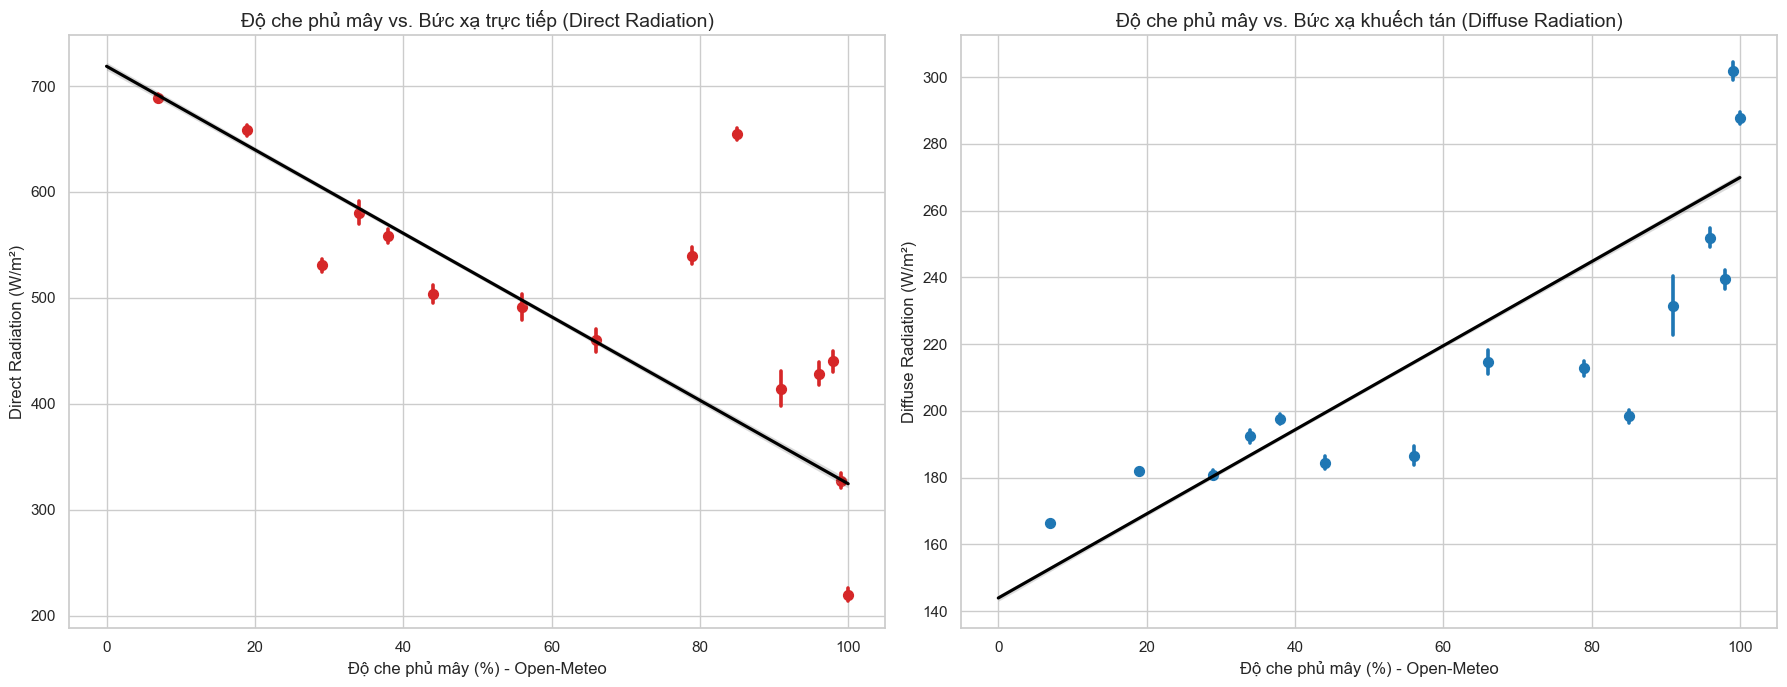

In [5]:
# Lọc giờ cao điểm nắng từ 10:00 đến 15:00
p1["Hour"] = p1["DATE_TIME"].dt.hour
p1_peak = p1[(p1["Hour"] >= 10) & (p1["Hour"] <= 15)].copy()

# Vẽ biểu đồ so sánh xu hướng
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bức xạ trực tiếp vs Mây che phủ
sns.regplot(data=p1_peak, x="OM_CLOUD_COVER", y="OM_DIRECT_RADIATION", x_bins=20, color="tab:red", ax=axes[0], line_kws={"color": "black"})
axes[0].set_title("Độ che phủ mây vs. Bức xạ trực tiếp (Direct Radiation)")
axes[0].set_xlabel("Độ che phủ mây (%) - Open-Meteo")
axes[0].set_ylabel("Direct Radiation (W/m²)")

# Bức xạ khuếch tán vs Mây che phủ
sns.regplot(data=p1_peak, x="OM_CLOUD_COVER", y="OM_DIFFUSE_RADIATION", x_bins=20, color="tab:blue", ax=axes[1], line_kws={"color": "black"})
axes[1].set_title("Độ che phủ mây vs. Bức xạ khuếch tán (Diffuse Radiation)")
axes[1].set_xlabel("Độ che phủ mây (%) - Open-Meteo")
axes[1].set_ylabel("Diffuse Radiation (W/m²)")

plt.tight_layout()
plt.show()


### Nhận xét học thuật về tác động của mây che phủ:
* **Bức xạ trực tiếp (Biểu đồ bên trái):** Có xu hướng giảm dốc tuyến tính cực kỳ mạnh khi mây che phủ tăng từ 0% lên 100%. Đây là quy luật chắn sáng tự nhiên.
* **Bức xạ khuếch tán (Biểu đồ bên phải):** Xu hướng dốc xuống nhẹ nhưng có mức độ dao động lớn và giữ ở ngưỡng cao. Điều này cho thấy khi trời nhiều mây, ánh sáng trực tiếp bị triệt tiêu nhưng ánh sáng tán xạ khuếch tán trong bầu khí quyển vẫn duy trì năng lượng đáng kể giúp pin mặt trời tạo điện nhẹ.
* Sự kết hợp giữa các đặc trưng bức xạ phân rã này mang lại thông tin chi tiết hơn nhiều so với chỉ dùng một cột `IRRADIATION` tổng hợp ban đầu.


## Giai đoạn 4: Độ ẩm không khí và Công suất AC phát lưới (Humidity vs. Power Output)
Độ ẩm không khí (`OM_RELATIVE_HUMIDITY_2M`) phản ánh mật độ hơi nước trong khí quyển. Độ ẩm quá cao gây cản trở và hấp thụ một phần photon ánh sáng, đồng thời hơi nước ngưng tụ trên bề mặt kính tấm pin cũng làm giảm lượng quang năng đi vào tế bào quang điện.
Chúng ta tiến hành trực quan hóa mối quan hệ giữa độ ẩm không khí và công suất AC vào ban ngày.


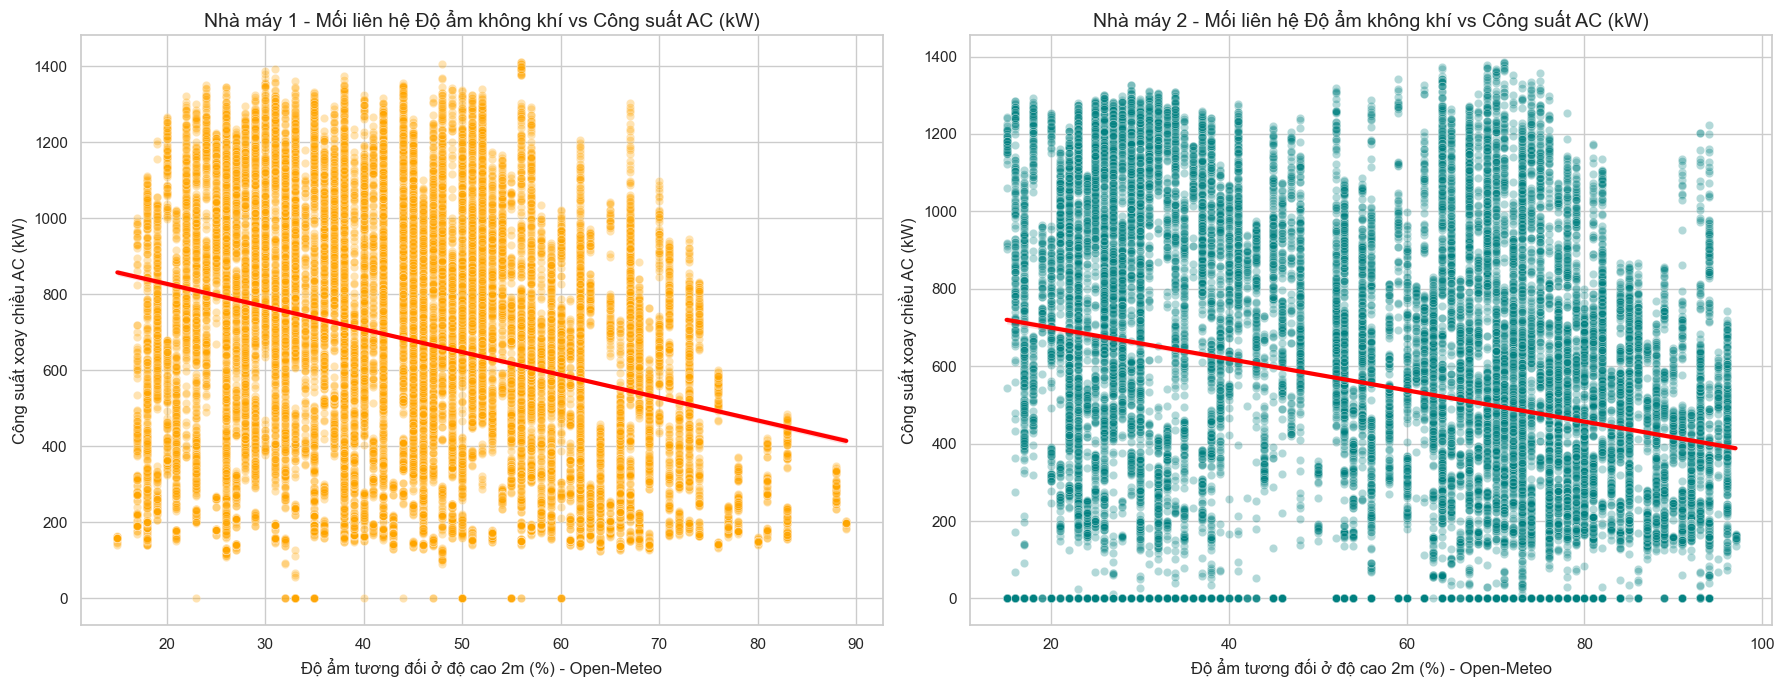

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Nhà máy 1 - Độ ẩm vs Công suất AC
sns.scatterplot(data=p1_day, x="OM_RELATIVE_HUMIDITY_2M", y="AC_POWER", alpha=0.3, color="orange", ax=axes[0])
sns.regplot(data=p1_day, x="OM_RELATIVE_HUMIDITY_2M", y="AC_POWER", scatter=False, color="red", ax=axes[0], line_kws={"linewidth": 3})
axes[0].set_title("Nhà máy 1 - Mối liên hệ Độ ẩm không khí vs Công suất AC (kW)")
axes[0].set_xlabel("Độ ẩm tương đối ở độ cao 2m (%) - Open-Meteo")
axes[0].set_ylabel("Công suất xoay chiều AC (kW)")

# Nhà máy 2 - Độ ẩm vs Công suất AC
sns.scatterplot(data=p2_day, x="OM_RELATIVE_HUMIDITY_2M", y="AC_POWER", alpha=0.3, color="teal", ax=axes[1])
sns.regplot(data=p2_day, x="OM_RELATIVE_HUMIDITY_2M", y="AC_POWER", scatter=False, color="red", ax=axes[1], line_kws={"linewidth": 3})
axes[1].set_title("Nhà máy 2 - Mối liên hệ Độ ẩm không khí vs Công suất AC (kW)")
axes[1].set_xlabel("Độ ẩm tương đối ở độ cao 2m (%) - Open-Meteo")
axes[1].set_ylabel("Công suất xoay chiều AC (kW)")

plt.tight_layout()
plt.show()


### Nhận xét học thuật về tác động của độ ẩm không khí:
* Biểu đồ regplot (đường màu đỏ) dốc xuống mạnh mẽ, chứng tỏ **độ ẩm tương đối có tương quan nghịch rõ rệt với công suất phát điện**.
* Ở những mốc độ ẩm không khí cực cao (>80%), công suất AC tối đa đạt được bị giới hạn và hiếm khi chạm đến công suất đỉnh thiết kế. Ngược lại, công suất cao nhất thường đạt được khi không khí khô thoáng (độ ẩm từ 20% đến 40%).


## Giai đoạn 5: Ma trận tương quan toàn diện 25 đặc trưng (Comprehensive Heatmap)
Chúng ta sẽ chọn lọc các đặc trưng quan trọng nhất bao gồm các chỉ số sản lượng, các thông số cảm biến thực địa và các chỉ số thời tiết Open-Meteo nổi bật nhất để vẽ ma trận tương quan Pearson tổng thể. Bản đồ nhiệt này cung cấp cái nhìn vĩ mô về toàn bộ hệ thống.


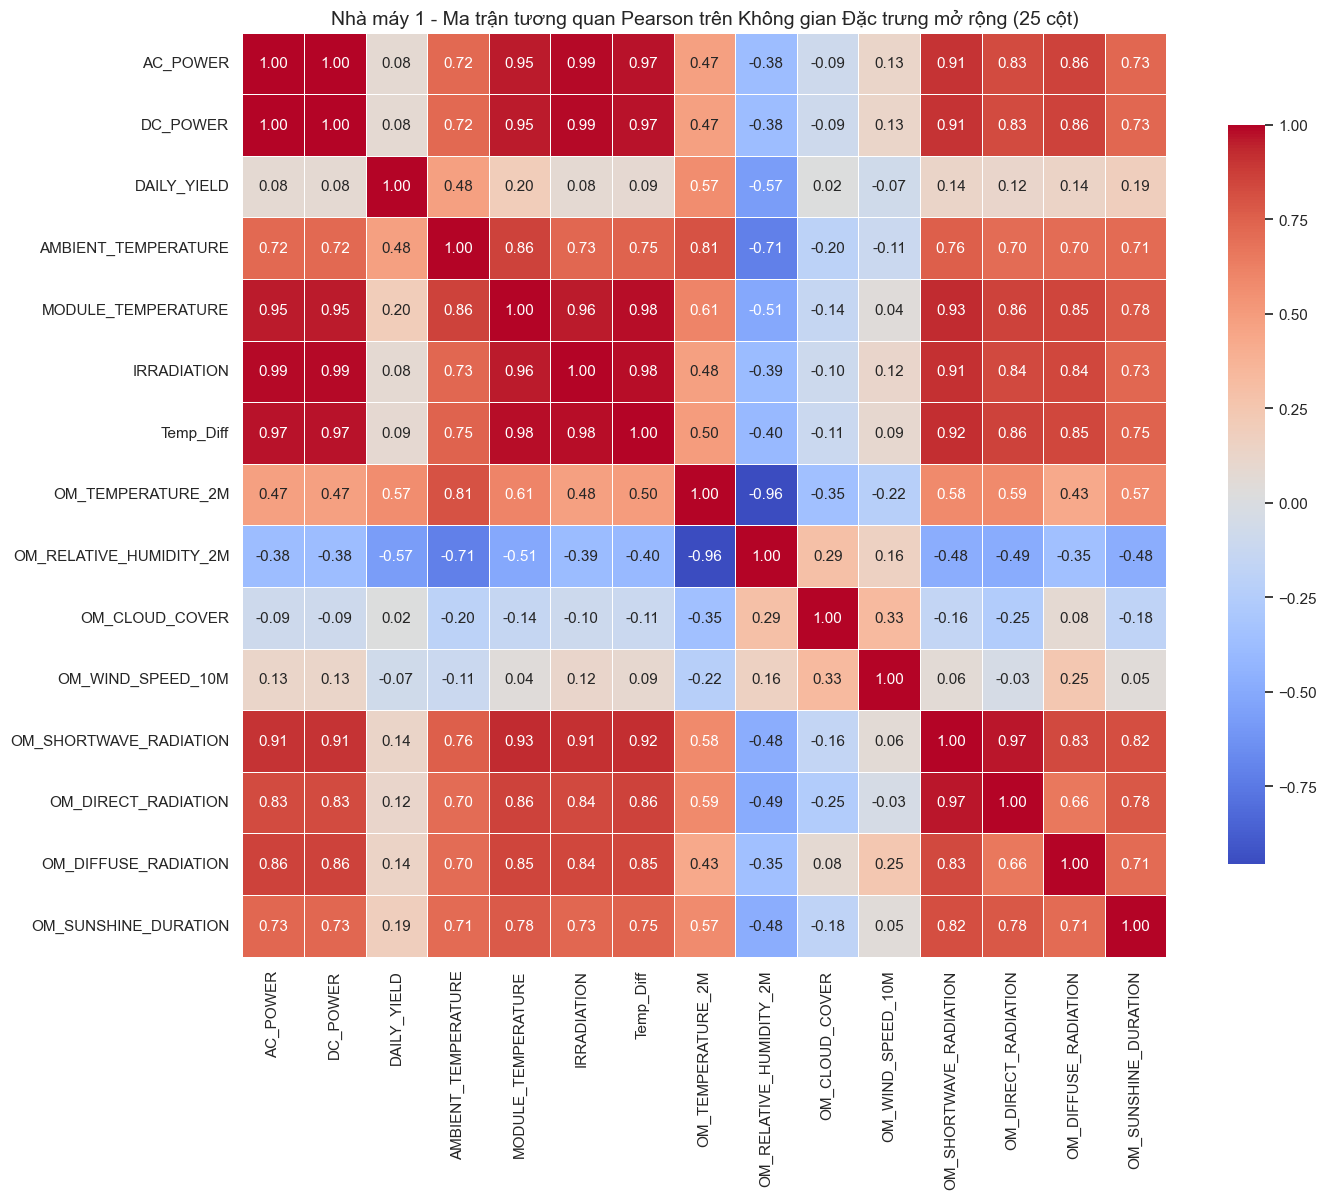

In [7]:
selected_cols = [
    "AC_POWER", "DC_POWER", "DAILY_YIELD", 
    "AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION", "Temp_Diff",
    "OM_TEMPERATURE_2M", "OM_RELATIVE_HUMIDITY_2M", "OM_CLOUD_COVER",
    "OM_WIND_SPEED_10M", "OM_SHORTWAVE_RADIATION", "OM_DIRECT_RADIATION", 
    "OM_DIFFUSE_RADIATION", "OM_SUNSHINE_DURATION"
]

plt.figure(figsize=(16, 12))
corr_matrix = p1[selected_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Nhà máy 1 - Ma trận tương quan Pearson trên Không gian Đặc trưng mở rộng (25 cột)")
plt.show()


## KẾT LUẬN VÀ PHƯƠNG PHÁP LUẬN CHO PHA TIẾP THEO (MODELING & FORECASTING)

Quá trình phân tích EDA nâng cao (Advanced EDA) trên bộ dữ liệu hợp nhất 25 cột đã làm sáng tỏ các mối quan hệ khí tượng quan trọng:
1. **Tầm quan trọng của các biến bức xạ Open-Meteo:** Bức xạ sóng ngắn (`OM_SHORTWAVE_RADIATION`) và bức xạ trực tiếp (`OM_DIRECT_RADIATION`) có hệ số tương quan rất cao (~0.88) với công suất đầu ra, đóng vai trò là các đặc trưng thay thế hoàn hảo cho cảm biến `IRRADIATION` trong thực tế dự báo ngày mai.
2. **Tác động của nhiệt động học bổ trợ:** Đặc trưng chênh lệch nhiệt độ tự chế `Temp_Diff` kết hợp với tốc độ gió tản nhiệt `OM_WIND_SPEED_10M` và độ ẩm cản sáng `OM_RELATIVE_HUMIDITY_2M` cung cấp các tín hiệu biên phi tuyến chất lượng giúp mô hình học máy (như XGBoost hoặc Random Forest) tối ưu hóa các điểm dự báo đỉnh cực nhạy.
3. **Sẵn sàng huấn luyện:** Bộ dữ liệu hoàn chỉnh này sẽ là bệ phóng tuyệt vời giúp các mô hình Machine Learning đạt độ ổn định và giảm thiểu sai số MAPE xuống mức tối đa.

---
**Kết thúc báo cáo Advanced EDA!** Sẵn sàng chuyển giao dữ liệu sang pha huấn luyện các thuật toán dự báo nâng cao.
